# IMDb Movie Score Prediction: Exploration Notebook


Main question:

> Can IMDb-style movie scores be predicted or explained using movie metadata and financial features?

## 1. Imports and paths

Run this first. The notebook assumes this file is inside a `notebooks/` folder in the repo:

```text
DataScienceProject/
├── data/
│   └── imdb_movies.csv
├── notebooks/
│   └── final_project_exploration.ipynb
├── src/
│   └── final_project_analysis.py
└── outputs/
```

In [312]:
from pathlib import Path
import json

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns

from sklearn.cluster import KMeans
from sklearn.compose import ColumnTransformer
from sklearn.decomposition import PCA
from sklearn.impute import SimpleImputer
from sklearn.linear_model import LinearRegression, LogisticRegression
from sklearn.metrics import (
    accuracy_score,
    balanced_accuracy_score,
    f1_score,
    mean_absolute_error,
    mean_squared_error,
    precision_score,
    r2_score,
    recall_score,
)
from sklearn.model_selection import train_test_split
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder, StandardScaler

sns.set_theme(style="whitegrid", context="notebook")

RANDOM_STATE = 42

# If this notebook is in /notebooks, parents[1] points to the project root.
PROJECT_ROOT = Path.cwd()
if PROJECT_ROOT.name == "notebooks":
    PROJECT_ROOT = PROJECT_ROOT.parent

DATA_PATH = PROJECT_ROOT / "data" / "imdb_movies.csv"
OUTPUT_DIR = PROJECT_ROOT / "outputs"
FIGURE_DIR = OUTPUT_DIR / "figures"

print("Project root:", PROJECT_ROOT)
print("Dataset path:", DATA_PATH)

Project root: c:\Users\craig\Documents\School\Intro to Data Science\Final Project\DataScienceProject
Dataset path: c:\Users\craig\Documents\School\Intro to Data Science\Final Project\DataScienceProject\data\imdb_movies.csv


## 2. Load the raw dataset

First, we inspect the original CSV before cleaning. This helps us understand what columns we have and what the data looks like.

In [313]:
raw_df = pd.read_csv(DATA_PATH)

print("Raw dataset shape:", raw_df.shape)
display(raw_df.head())
display(raw_df.info())

Raw dataset shape: (10178, 12)


,names,date_x,score,genre,overview,crew,orig_title,status,orig_lang,budget_x,revenue,country
0,Creed III,03/02/2023,73.0,"Drama, Action","After dominating the boxing world, Adonis Cree...","Michael B. Jordan, Adonis Creed, Tessa Thompso...",Creed III,Released,English,75000000.0,2.716167e+08,AU
1,Avatar: The Way of Water,12/15/2022,78.0,"Science Fiction, Adventure, Action",Set more than a decade after the events of the...,"Sam Worthington, Jake Sully, Zoe Saldaña, Neyt...",Avatar: The Way of Water,Released,English,460000000.0,2.316795e+09,AU
2,The Super Mario Bros. Movie,04/05/2023,76.0,"Animation, Adventure, Family, Fantasy, Comedy","While working underground to fix a water main,...","Chris Pratt, Mario (voice), Anya Taylor-Joy, P...",The Super Mario Bros. Movie,Released,English,100000000.0,7.244590e+08,AU
3,Mummies,01/05/2023,70.0,"Animation, Comedy, Family, Adventure, Fantasy","Through a series of unfortunate events, three ...","Óscar Barberán, Thut (voice), Ana Esther Albor...",Momias,Released,"Spanish, Castilian",12300000.0,3.420000e+07,AU
4,Supercell,03/17/2023,61.0,Action,Good-hearted teenager William always lived in ...,"Skeet Ulrich, Roy Cameron, Anne Heche, Dr Quin...",Supercell,Released,English,77000000.0,3.409420e+08,US


<class 'pandas.DataFrame'>
RangeIndex: 10178 entries, 0 to 10177
Data columns (total 12 columns):
 #   Column      Non-Null Count  Dtype  
---  ------      --------------  -----  
 0   names       10178 non-null  str    
 1   date_x      10178 non-null  str    
 2   score       10178 non-null  float64
 3   genre       10093 non-null  str    
 4   overview    10178 non-null  str    
 5   crew        10122 non-null  str    
 6   orig_title  10178 non-null  str    
 7   status      10178 non-null  str    
 8   orig_lang   10178 non-null  str    
 9   budget_x    10178 non-null  float64
 10  revenue     10178 non-null  float64
 11  country     10178 non-null  str    
dtypes: float64(3), str(9)
memory usage: 954.3 KB


None

## 3. Basic raw-data checks

These checks help us explain the dataset quality in the report: missing values, score range, and suspicious zero values.

In [314]:
raw_summary = pd.DataFrame({
    "missing_count": raw_df.isna().sum(),
    "missing_rate": raw_df.isna().mean(),
    "dtype": raw_df.dtypes.astype(str),
})

display(raw_summary)

budget_col = "budget_x" if "budget_x" in raw_df.columns else "budget"

print("Raw score summary:")
display(pd.to_numeric(raw_df["score"], errors="coerce").describe())

print("Zero budget rate:", (pd.to_numeric(raw_df[budget_col], errors="coerce") == 0).mean())
print("Zero revenue rate:", (pd.to_numeric(raw_df["revenue"], errors="coerce") == 0).mean())

,missing_count,missing_rate,dtype
names,0,0.000000,str
date_x,0,0.000000,str
score,0,0.000000,float64
genre,85,0.008351,str
overview,0,0.000000,str
crew,56,0.005502,str
orig_title,0,0.000000,str
status,0,0.000000,str
orig_lang,0,0.000000,str
budget_x,0,0.000000,float64


Raw score summary:


count    10178.000000
mean        63.497052
std         13.537012
min          0.000000
25%         59.000000
50%         65.000000
75%         71.000000
max        100.000000
Name: score, dtype: float64

Zero budget rate: 0.0
Zero revenue rate: 0.007172332481823541


## 4. Cleaning helper functions

These functions mirror the project script, but are included here so the notebook is self-contained.

In [315]:
NUMERIC_MODEL_FEATURES = [
    "log_budget",
    "log_revenue",
    "log_profit_shifted",
    "roi_capped",
    "release_year",
]

CATEGORICAL_MODEL_FEATURES = ["main_genre", "language", "country"]

def normalize_text(value: object) -> str:
    if pd.isna(value):
        return "Unknown"

    text = str(value).replace("\xa0", " ").strip()
    return text if text else "Unknown"


def group_rare_categories(
    df: pd.DataFrame,
    column: str,
    min_count: int = 50,
) -> pd.Series:
    counts = df[column].value_counts()
    common_values = counts[counts >= min_count].index
    return df[column].where(df[column].isin(common_values), "Other")

## 5. Clean and engineer features

This section creates the main modeling dataset.

Important engineered features:

- `profit = revenue - budget`
- `roi = profit / budget`
- `roi_capped`: ROI capped at the 1st and 99th percentiles to reduce extreme outliers
- `log_budget` and `log_revenue`: log transforms to reduce skew
- `log_profit_shifted`: profit can be negative, so it is shifted before log-transforming
- `main_genre`: the first listed genre

In [316]:
df = raw_df.copy()

df = df.rename(
    columns={
        "names": "title",
        "date_x": "release_date",
        "budget_x": "budget",
        "orig_lang": "language",
    }
)

df["release_date"] = pd.to_datetime(df["release_date"], errors="coerce")
df["release_year"] = df["release_date"].dt.year

df["genre"] = df["genre"].apply(normalize_text)
df["main_genre"] = df["genre"].str.split(",").str[0].apply(normalize_text)
df["language"] = df["language"].apply(normalize_text)
df["country"] = df["country"].apply(normalize_text)
df["status"] = df["status"].apply(normalize_text)

numeric_cols = ["score", "budget", "revenue"]
for col in numeric_cols:
    df[col] = pd.to_numeric(df[col], errors="coerce")

df["profit"] = df["revenue"] - df["budget"]

df["roi"] = np.where(
    df["budget"] > 0,
    df["profit"] / df["budget"],
    np.nan,
)

roi_bounds = df["roi"].replace([np.inf, -np.inf], np.nan).quantile([0.01, 0.99])
df["roi_capped"] = df["roi"].clip(
    lower=roi_bounds.loc[0.01],
    upper=roi_bounds.loc[0.99],
)

df["log_budget"] = np.log1p(df["budget"].clip(lower=0))
df["log_revenue"] = np.log1p(df["revenue"].clip(lower=0))
df["log_profit_shifted"] = np.log1p(
    (df["profit"] - df["profit"].min()).clip(lower=0)
)

cleaned = df[df["status"].eq("Released")].copy()
cleaned = cleaned.dropna(subset=["score", "budget", "revenue"])
cleaned = cleaned[
    (cleaned["score"] > 0)
    & (cleaned["budget"] >= 0)
    & (cleaned["revenue"] >= 0)
]

for col in ["main_genre", "language", "country"]:
    cleaned[col] = group_rare_categories(cleaned, col, min_count=50)

print("Cleaned dataset shape:", cleaned.shape)
display(cleaned.head())

Cleaned dataset shape: (9967, 20)


,title,release_date,score,genre,overview,crew,orig_title,status,language,budget,revenue,country,release_year,main_genre,profit,roi,roi_capped,log_budget,log_revenue,log_profit_shifted
0,Creed III,2023-03-02,73.0,"Drama, Action","After dominating the boxing world, Adonis Cree...","Michael B. Jordan, Adonis Creed, Tessa Thompso...",Creed III,Released,English,75000000.0,2.716167e+08,AU,2023,Drama,1.966167e+08,2.621556,2.621556,18.132999,19.419902,20.100795
1,Avatar: The Way of Water,2022-12-15,78.0,"Science Fiction, Adventure, Action",Set more than a decade after the events of the...,"Sam Worthington, Jake Sully, Zoe Saldaña, Neyt...",Avatar: The Way of Water,Released,English,460000000.0,2.316795e+09,AU,2022,Science Fiction,1.856795e+09,4.036511,4.036511,19.946737,21.563451,21.510265
2,The Super Mario Bros. Movie,2023-04-05,76.0,"Animation, Adventure, Family, Fantasy, Comedy","While working underground to fix a water main,...","Chris Pratt, Mario (voice), Anya Taylor-Joy, P...",The Super Mario Bros. Movie,Released,English,100000000.0,7.244590e+08,AU,2023,Animation,6.244590e+08,6.244590,6.244590,18.420681,20.400936,20.687078
3,Mummies,2023-01-05,70.0,"Animation, Comedy, Family, Adventure, Fantasy","Through a series of unfortunate events, three ...","Óscar Barberán, Thut (voice), Ana Esther Albor...",Momias,Released,"Spanish, Castilian",12300000.0,3.420000e+07,AU,2023,Animation,2.190000e+07,1.780488,1.780488,16.325110,17.347736,19.706878
4,Supercell,2023-03-17,61.0,Action,Good-hearted teenager William always lived in ...,"Skeet Ulrich, Roy Cameron, Anne Heche, Dr Quin...",Supercell,Released,English,77000000.0,3.409420e+08,US,2023,Action,2.639420e+08,3.427818,3.427818,18.159316,19.647223,20.218989


## 6. Data quality summary

This table summarizes how much cleaning was needed. It is useful for the Methodology or Data section of the report.

In [317]:
data_quality_summary = pd.DataFrame([{
    "original_rows": len(raw_df),
    "cleaned_rows": len(cleaned),
    "rows_removed": len(raw_df) - len(cleaned),
    "percent_rows_removed": round((len(raw_df) - len(cleaned)) / len(raw_df), 4),
    "missing_genre_count": int(raw_df["genre"].isna().sum()),
    "missing_genre_rate": round(float(raw_df["genre"].isna().mean()), 4),
    "missing_crew_count": int(raw_df["crew"].isna().sum()) if "crew" in raw_df.columns else None,
    "missing_crew_rate": round(float(raw_df["crew"].isna().mean()), 4) if "crew" in raw_df.columns else None,
    "zero_budget_count": int((pd.to_numeric(raw_df[budget_col], errors="coerce") == 0).sum()),
    "zero_budget_rate": round(float((pd.to_numeric(raw_df[budget_col], errors="coerce") == 0).mean()), 4),
    "zero_revenue_count": int((pd.to_numeric(raw_df["revenue"], errors="coerce") == 0).sum()),
    "zero_revenue_rate": round(float((pd.to_numeric(raw_df["revenue"], errors="coerce") == 0).mean()), 4),
    "raw_score_min": float(pd.to_numeric(raw_df["score"], errors="coerce").min()),
    "raw_score_max": float(pd.to_numeric(raw_df["score"], errors="coerce").max()),
    "cleaned_score_min": float(cleaned["score"].min()),
    "cleaned_score_max": float(cleaned["score"].max()),
    "cleaned_score_mean": float(cleaned["score"].mean()),
    "cleaned_score_median": float(cleaned["score"].median()),
}])

display(data_quality_summary.T)

,0
original_rows,10178.000000
cleaned_rows,9967.000000
rows_removed,211.000000
percent_rows_removed,0.020700
missing_genre_count,85.000000
missing_genre_rate,0.008400
missing_crew_count,56.000000
missing_crew_rate,0.005500
zero_budget_count,0.000000
zero_budget_rate,0.000000


## 7. EDA: score distribution

This shows the distribution of the target variable, `score`.

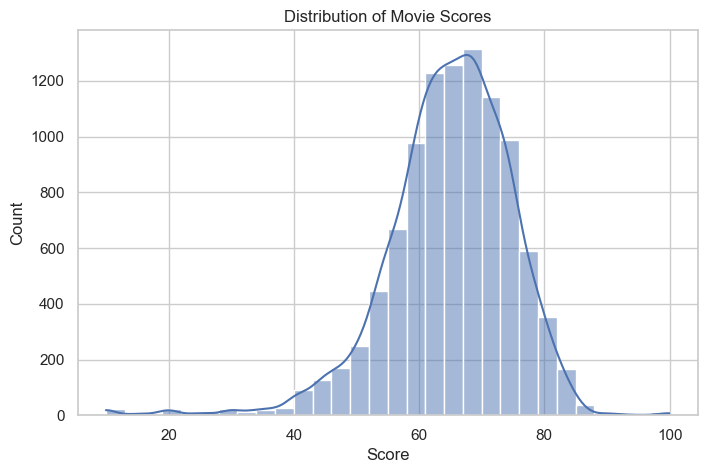

count    9967.000000
mean       64.841276
std         9.998028
min        10.000000
25%        60.000000
50%        66.000000
75%        72.000000
max       100.000000
Name: score, dtype: float64

In [318]:
plt.figure(figsize=(8, 5))
sns.histplot(cleaned["score"], bins=30, kde=True)
plt.title("Distribution of Movie Scores")
plt.xlabel("Score")
plt.ylabel("Count")
plt.show()

display(cleaned["score"].describe())

## 8. EDA: raw vs log-transformed financial variables

Budget and revenue are highly skewed. The log versions are easier for the model to work with and easier to visualize.

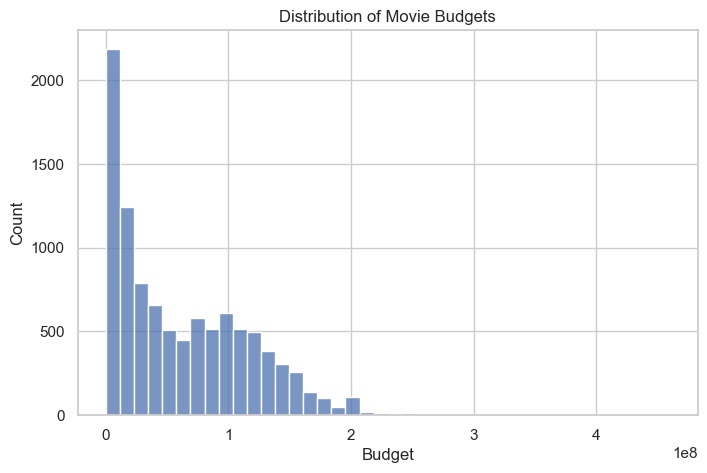

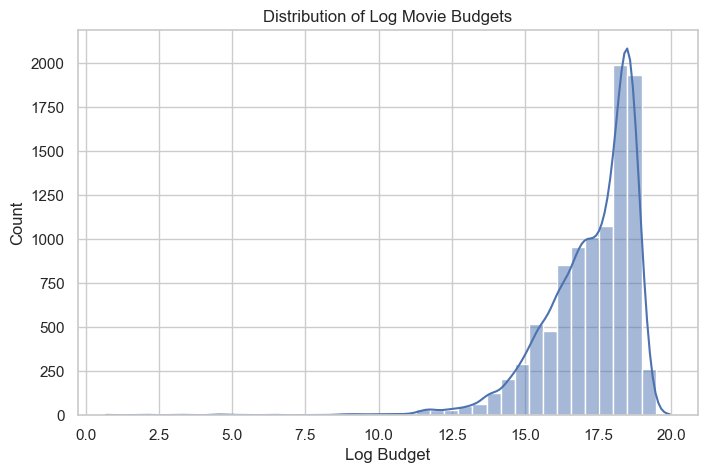

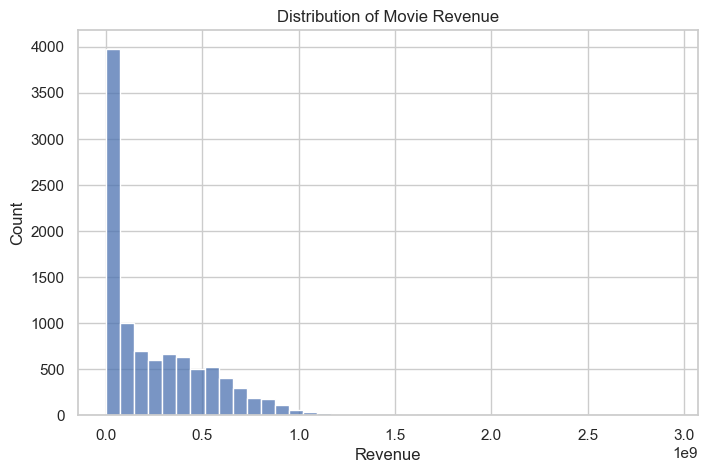

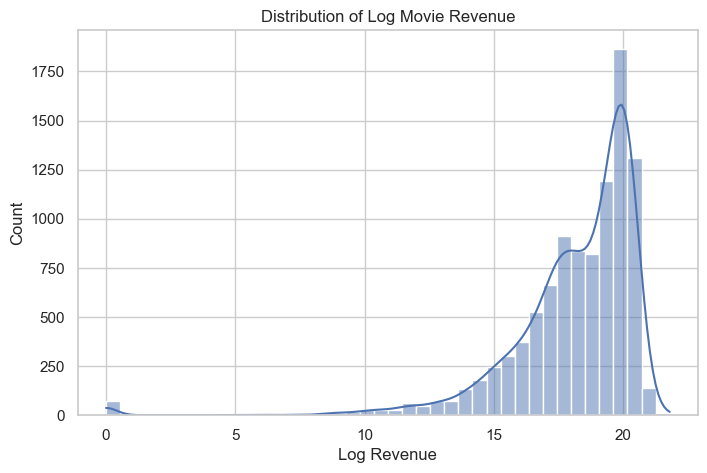

In [319]:
plt.figure(figsize=(8, 5))
sns.histplot(cleaned["budget"], bins=40)
plt.title("Distribution of Movie Budgets")
plt.xlabel("Budget")
plt.show()

plt.figure(figsize=(8, 5))
sns.histplot(cleaned["log_budget"], bins=40, kde=True)
plt.title("Distribution of Log Movie Budgets")
plt.xlabel("Log Budget")
plt.show()

plt.figure(figsize=(8, 5))
sns.histplot(cleaned["revenue"], bins=40)
plt.title("Distribution of Movie Revenue")
plt.xlabel("Revenue")
plt.show()

plt.figure(figsize=(8, 5))
sns.histplot(cleaned["log_revenue"], bins=40, kde=True)
plt.title("Distribution of Log Movie Revenue")
plt.xlabel("Log Revenue")
plt.show()

## 9. EDA: budget/revenue vs score

These scatter plots help us check whether financial variables have an obvious relationship with score.

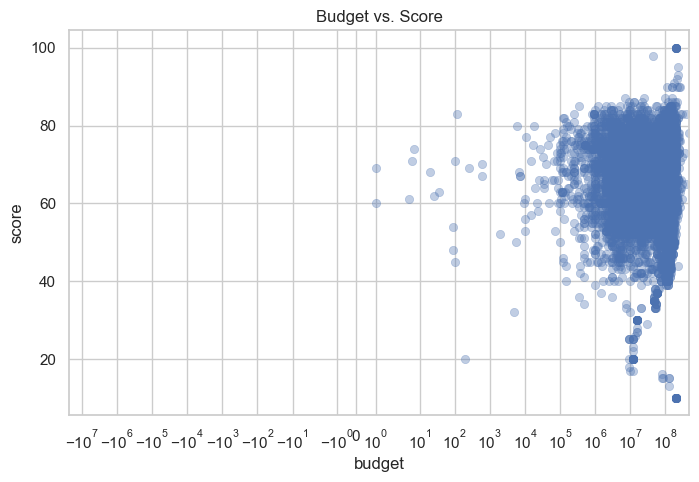

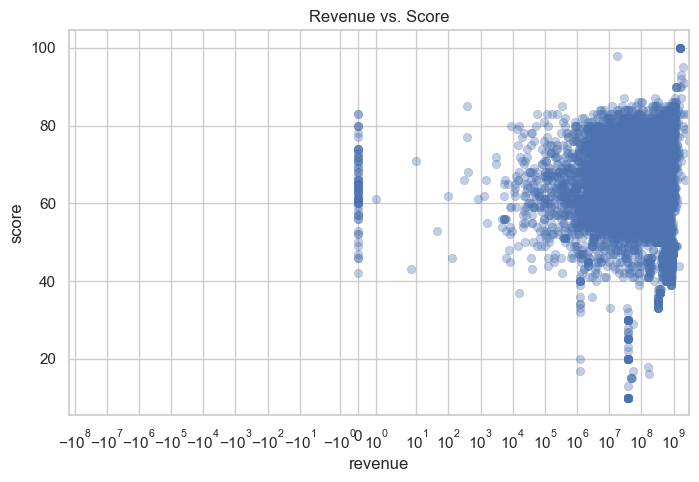

In [320]:
plt.figure(figsize=(8, 5))
sns.scatterplot(data=cleaned, x="budget", y="score", alpha=0.35, edgecolor=None)
plt.xscale("symlog")
plt.title("Budget vs. Score")
plt.show()

plt.figure(figsize=(8, 5))
sns.scatterplot(data=cleaned, x="revenue", y="score", alpha=0.35, edgecolor=None)
plt.xscale("symlog")
plt.title("Revenue vs. Score")
plt.show()

## 10. EDA: score by genre, language, and country

These boxplots compare score distributions across common categories.

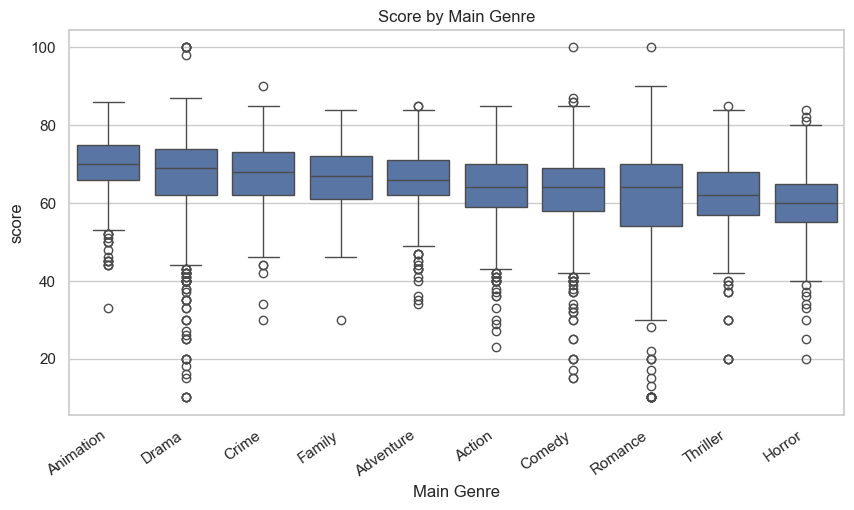

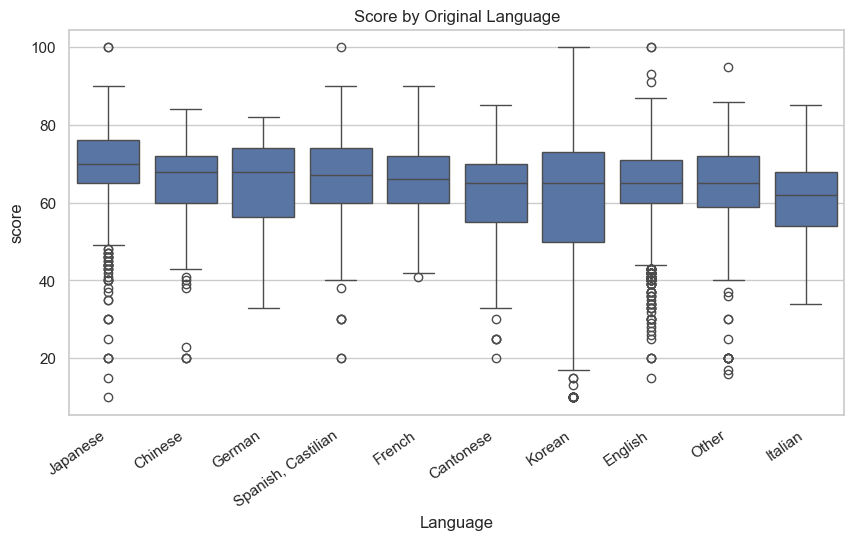

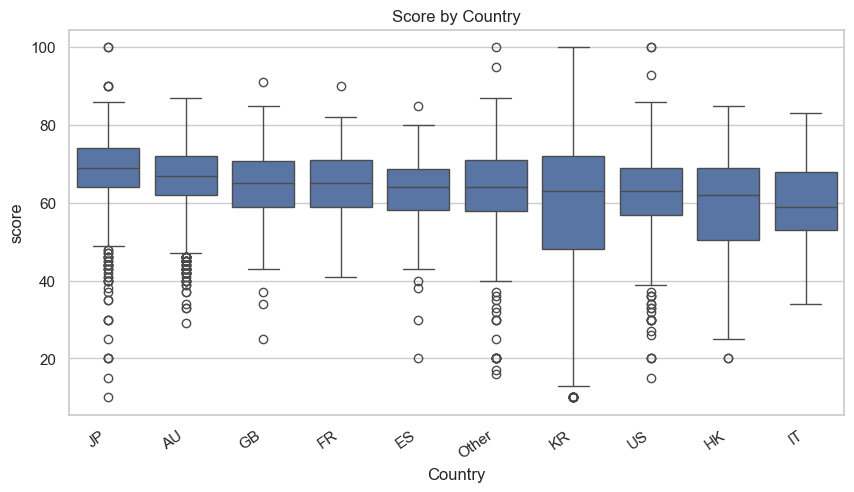

In [321]:
for col, title in [
    ("main_genre", "Score by Main Genre"),
    ("language", "Score by Original Language"),
    ("country", "Score by Country"),
]:
    top_values = cleaned[col].value_counts().head(10).index
    subset = cleaned[cleaned[col].isin(top_values)].copy()

    plt.figure(figsize=(10, 5))
    order = subset.groupby(col)["score"].median().sort_values(ascending=False).index

    sns.boxplot(data=subset, x=col, y="score", order=order)
    plt.title(title)
    plt.xlabel(col.replace("_", " ").title())
    plt.xticks(rotation=35, ha="right")
    plt.show()

## 11. EDA: correlation heatmap

This shows associations among numeric variables. These are **not causal claims**; they only show how variables move together in this dataset.

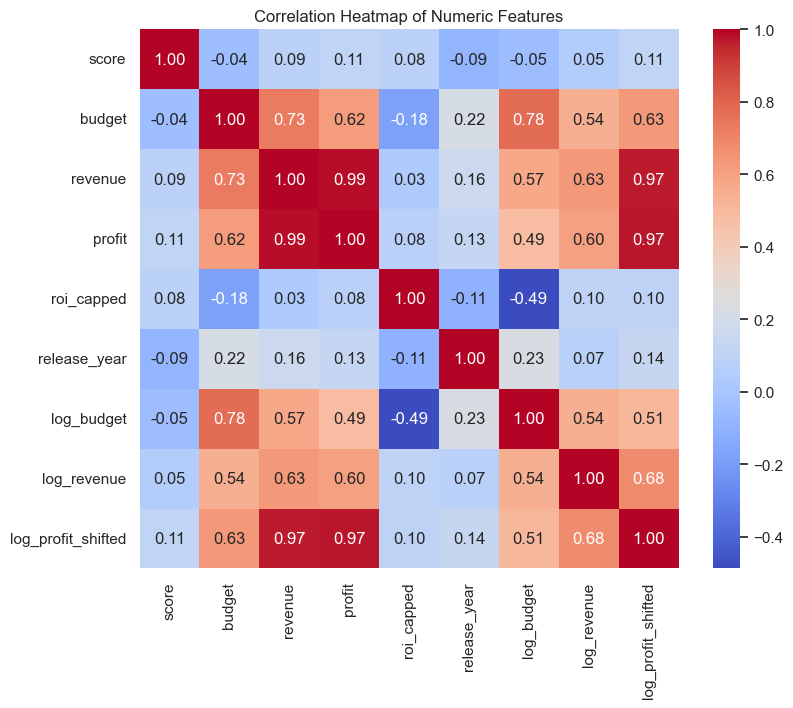

In [322]:
numeric_corr_cols = [
    "score",
    "budget",
    "revenue",
    "profit",
    "roi_capped",
    "release_year",
    "log_budget",
    "log_revenue",
    "log_profit_shifted",
]

plt.figure(figsize=(9, 7))
corr = cleaned[numeric_corr_cols].corr()
sns.heatmap(corr, annot=True, fmt=".2f", cmap="coolwarm", square=True)
plt.title("Correlation Heatmap of Numeric Features")
plt.show()

## 12. Modeling helper functions

These functions create preprocessing pipelines and compute regression/classification metrics.

In [323]:
def make_preprocessor(
    numeric_features: list[str],
    categorical_features: list[str],
) -> ColumnTransformer:
    numeric_pipeline = Pipeline(
        steps=[
            ("imputer", SimpleImputer(strategy="median")),
            ("scaler", StandardScaler()),
        ]
    )

    categorical_pipeline = Pipeline(
        steps=[
            ("imputer", SimpleImputer(strategy="most_frequent")),
            ("onehot", OneHotEncoder(handle_unknown="ignore", sparse_output=False)),
        ]
    )

    return ColumnTransformer(
        transformers=[
            ("numeric", numeric_pipeline, numeric_features),
            ("categorical", categorical_pipeline, categorical_features),
        ]
    )


def regression_metrics(y_true, preds, model_name):
    return {
        "model": model_name,
        "rmse": float(np.sqrt(mean_squared_error(y_true, preds))),
        "mae": float(mean_absolute_error(y_true, preds)),
        "r2": float(r2_score(y_true, preds)),
    }


def classification_metrics(y_true, preds, model_name, category_distribution):
    return {
        "model": model_name,
        "accuracy": float(accuracy_score(y_true, preds)),
        "balanced_accuracy": float(balanced_accuracy_score(y_true, preds)),
        "precision_macro": float(precision_score(y_true, preds, average="macro", zero_division=0)),
        "recall_macro": float(recall_score(y_true, preds, average="macro", zero_division=0)),
        "f1_macro": float(f1_score(y_true, preds, average="macro", zero_division=0)),
        "precision_weighted": float(precision_score(y_true, preds, average="weighted", zero_division=0)),
        "recall_weighted": float(recall_score(y_true, preds, average="weighted", zero_division=0)),
        "f1_weighted": float(f1_score(y_true, preds, average="weighted", zero_division=0)),
        "low_rate": float(category_distribution.get("low", 0)),
        "medium_rate": float(category_distribution.get("medium", 0)),
        "high_rate": float(category_distribution.get("high", 0)),
    }

## 13. Regression Model 0: mean score baseline

This is the simplest possible baseline: always predict the average score from the training set.

In [324]:
y = cleaned["score"]

y_train, y_test = train_test_split(
    y,
    test_size=0.2,
    random_state=RANDOM_STATE,
)

train_mean = y_train.mean()
mean_prediction = np.full(shape=len(y_test), fill_value=train_mean)

mean_baseline_result = regression_metrics(
    y_test,
    mean_prediction,
    "Mean score baseline",
)

mean_baseline_result

{'model': 'Mean score baseline',
 'rmse': 10.329463868315067,
 'mae': 7.717587165107513,
 'r2': -0.0005169144241685686}

## 14. Regression Model 1: simple linear regression baseline

This baseline uses only budget and revenue.

In [325]:
X = cleaned[["budget", "revenue"]]
y = cleaned["score"]

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=RANDOM_STATE,
)

baseline_model = Pipeline(
    steps=[
        ("imputer", SimpleImputer(strategy="median")),
        ("scaler", StandardScaler()),
        ("regressor", LinearRegression()),
    ]
)

baseline_model.fit(X_train, y_train)
baseline_preds = baseline_model.predict(X_test)

baseline_result = regression_metrics(
    y_test,
    baseline_preds,
    "Baseline linear regression",
)

baseline_result

{'model': 'Baseline linear regression',
 'rmse': 10.12175488797592,
 'mae': 7.547620941370385,
 'r2': 0.03931611538501267}

## 15. Regression Model 2: improved linear regression

This model uses engineered numeric features and one-hot encoded categorical metadata.

In [326]:
X = cleaned[NUMERIC_MODEL_FEATURES + CATEGORICAL_MODEL_FEATURES]
y = cleaned["score"]

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=RANDOM_STATE,
)

improved_model = Pipeline(
    steps=[
        ("preprocessor", make_preprocessor(NUMERIC_MODEL_FEATURES, CATEGORICAL_MODEL_FEATURES)),
        ("regressor", LinearRegression()),
    ]
)

improved_model.fit(X_train, y_train)
improved_preds = improved_model.predict(X_test)

improved_result = regression_metrics(
    y_test,
    improved_preds,
    "Improved linear regression",
)

improved_result

{'model': 'Improved linear regression',
 'rmse': 9.21969837411535,
 'mae': 6.777818334114462,
 'r2': 0.2029192886187231}

## 16. Regression results summary

This table compares the regression models.

In [327]:
regression_results = pd.DataFrame([
    mean_baseline_result,
    baseline_result,
    improved_result,
])

display(regression_results)

,model,rmse,mae,r2
0,Mean score baseline,10.329464,7.717587,-0.000517
1,Baseline linear regression,10.121755,7.547621,0.039316
2,Improved linear regression,9.219698,6.777818,0.202919


## 17. Regression coefficients

Since the improved model is linear regression, we can inspect coefficients.  
Be careful: coefficients are associations, not causal effects.

,feature,coefficient,absolute_coefficient
44,categorical__country_KR,-7.050592,7.050592
34,categorical__country_AU,6.355741,6.355741
41,categorical__country_HK,-5.888997,5.888997
45,categorical__country_MX,5.410552,5.410552
14,categorical__main_genre_Horror,-5.012439,5.012439
37,categorical__country_DE,-4.958167,4.958167
15,categorical__main_genre_Music,4.492395,4.492395
40,categorical__country_GB,4.061065,4.061065
22,categorical__main_genre_Western,3.846165,3.846165
17,categorical__main_genre_Other,-3.753956,3.753956


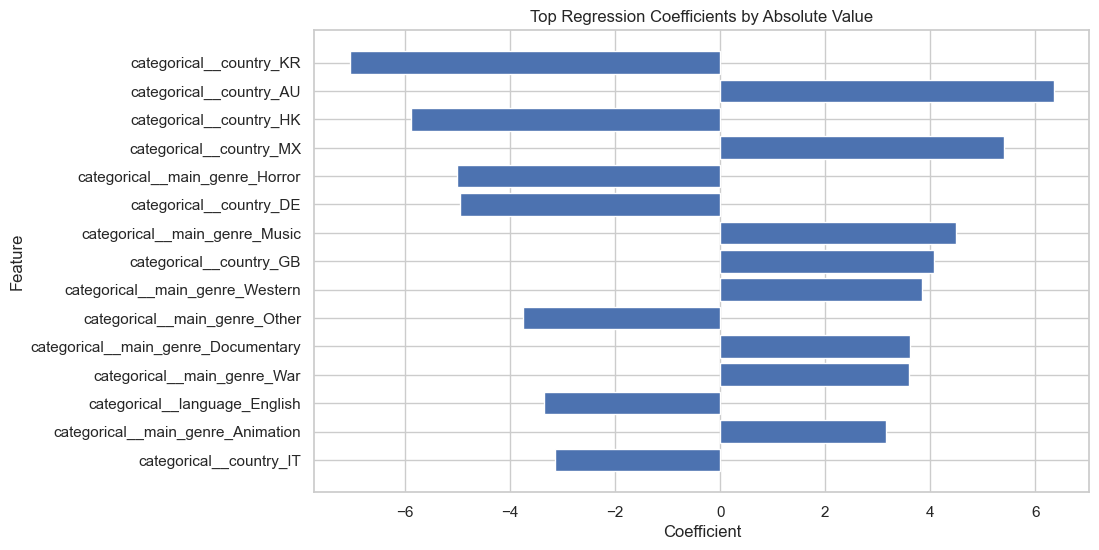

In [328]:
preprocessor = improved_model.named_steps["preprocessor"]
regressor = improved_model.named_steps["regressor"]

feature_names = preprocessor.get_feature_names_out()
coefficients = regressor.coef_

coef_df = pd.DataFrame({
    "feature": feature_names,
    "coefficient": coefficients,
    "absolute_coefficient": np.abs(coefficients),
}).sort_values("absolute_coefficient", ascending=False)

display(coef_df.head(20))

plt.figure(figsize=(10, 6))
top_coef = coef_df.head(15).iloc[::-1]
plt.barh(top_coef["feature"], top_coef["coefficient"])
plt.title("Top Regression Coefficients by Absolute Value")
plt.xlabel("Coefficient")
plt.ylabel("Feature")
plt.show()

## 18. Classification target: score quantile categories

Instead of using fixed score cutoffs, we split scores into three roughly balanced quantile groups:

- low
- medium
- high

This makes classification fairer than using fixed bins where one category might dominate.

In [329]:
def add_score_category(df: pd.DataFrame):
    data = df.copy()

    _, bin_edges = pd.qcut(
        data["score"],
        q=3,
        retbins=True,
        duplicates="drop",
    )

    labels = ["low", "medium", "high"][: len(bin_edges) - 1]

    data["score_category"] = pd.cut(
        data["score"],
        bins=bin_edges,
        labels=labels,
        include_lowest=True,
    )

    data = data.dropna(subset=["score_category"])

    cutoffs = pd.DataFrame([
        {
            "category": label,
            "score_lower_bound": float(bin_edges[i]),
            "score_upper_bound": float(bin_edges[i + 1]),
        }
        for i, label in enumerate(labels)
    ])

    return data, cutoffs


classification_data, score_cutoffs = add_score_category(cleaned)

display(score_cutoffs)
display(classification_data["score_category"].value_counts(normalize=True).rename("proportion"))

,category,score_lower_bound,score_upper_bound
0,low,10.0,62.0
1,medium,62.0,69.0
2,high,69.0,100.0


score_category
low       0.367713
high      0.330591
medium    0.301696
Name: proportion, dtype: float64

## 19. Classification baseline: majority class

This baseline always predicts the most common category. The logistic regression classifier should beat this.

In [330]:
y = classification_data["score_category"].astype(str)

y_train, y_test = train_test_split(
    y,
    test_size=0.2,
    random_state=RANDOM_STATE,
    stratify=y,
)

majority_class = y_train.mode()[0]
majority_preds = np.full(shape=len(y_test), fill_value=majority_class)
category_distribution = y.value_counts(normalize=True).to_dict()

classification_baseline_result = classification_metrics(
    y_test,
    majority_preds,
    "Majority class baseline: score category",
    category_distribution,
)

classification_baseline_result

{'model': 'Majority class baseline: score category',
 'accuracy': 0.3676028084252758,
 'balanced_accuracy': 0.3333333333333333,
 'precision_macro': 0.12253426947509194,
 'recall_macro': 0.3333333333333333,
 'f1_macro': 0.17919569734751253,
 'precision_weighted': 0.13513182476215005,
 'recall_weighted': 0.3676028084252758,
 'f1_weighted': 0.1976185248080141,
 'low_rate': 0.3677134543995184,
 'medium_rate': 0.3016955954650346,
 'high_rate': 0.330590950135447}

## 20. Logistic regression classification model

This model tries to predict whether a movie belongs in the low, medium, or high score group.

In [331]:
X = classification_data[NUMERIC_MODEL_FEATURES + CATEGORICAL_MODEL_FEATURES]
y = classification_data["score_category"].astype(str)

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=RANDOM_STATE,
    stratify=y,
)

classification_model = Pipeline(
    steps=[
        ("preprocessor", make_preprocessor(NUMERIC_MODEL_FEATURES, CATEGORICAL_MODEL_FEATURES)),
        ("classifier", LogisticRegression(max_iter=2000, class_weight="balanced", random_state=RANDOM_STATE)),
    ]
)

classification_model.fit(X_train, y_train)
classification_preds = classification_model.predict(X_test)

classification_result = classification_metrics(
    y_test,
    classification_preds,
    "Logistic regression classification: score quantile category",
    category_distribution,
)

classification_result

{'model': 'Logistic regression classification: score quantile category',
 'accuracy': 0.5160481444332999,
 'balanced_accuracy': 0.5101492466011042,
 'precision_macro': 0.5066437841964891,
 'recall_macro': 0.5101492466011042,
 'f1_macro': 0.5079635221736085,
 'precision_weighted': 0.5121549565384701,
 'recall_weighted': 0.5160481444332999,
 'f1_weighted': 0.5136836110584886,
 'low_rate': 0.3677134543995184,
 'medium_rate': 0.3016955954650346,
 'high_rate': 0.330590950135447}

## 21. Classification results summary

This compares the majority-class baseline and logistic regression.

In [332]:
classification_results = pd.DataFrame([
    classification_baseline_result,
    classification_result,
])

display(classification_results)

,model,accuracy,balanced_accuracy,precision_macro,recall_macro,f1_macro,precision_weighted,recall_weighted,f1_weighted,low_rate,medium_rate,high_rate
0,Majority class baseline: score category,0.367603,0.333333,0.122534,0.333333,0.179196,0.135132,0.367603,0.197619,0.367713,0.301696,0.330591
1,Logistic regression classification: score quan...,0.516048,0.510149,0.506644,0.510149,0.507964,0.512155,0.516048,0.513684,0.367713,0.301696,0.330591


## 22. Confusion matrix and classification error analysis

The confusion matrix shows what categories the model confuses.

Predicted,low,medium,high
Actual,,,
low,405,209,119
medium,203,216,183
high,114,137,408


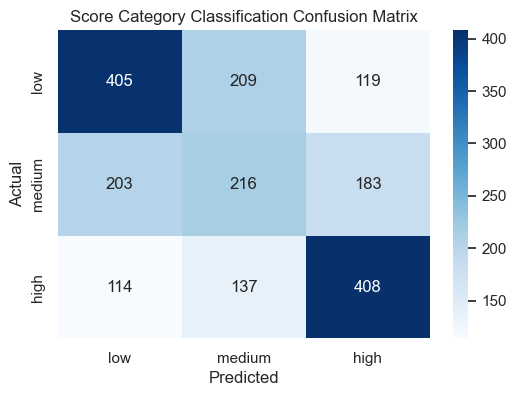

,actual_count,predicted_count,correct_predictions,recall,precision
low,733,722,405,0.5525,0.5609
medium,602,562,216,0.3588,0.3843
high,659,710,408,0.6191,0.5746


In [333]:
labels = ["low", "medium", "high"]

confusion = pd.crosstab(
    y_test,
    classification_preds,
    rownames=["Actual"],
    colnames=["Predicted"],
    dropna=False,
).reindex(index=labels, columns=labels, fill_value=0)

display(confusion)

plt.figure(figsize=(6, 4))
sns.heatmap(confusion, annot=True, fmt="d", cmap="Blues")
plt.title("Score Category Classification Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()

actual_counts = confusion.sum(axis=1)
predicted_counts = confusion.sum(axis=0)
correct_counts = pd.Series(np.diag(confusion), index=labels)

error_analysis = pd.DataFrame({
    "actual_count": actual_counts,
    "predicted_count": predicted_counts,
    "correct_predictions": correct_counts,
    "recall": correct_counts / actual_counts,
    "precision": correct_counts / predicted_counts.replace(0, np.nan),
}).round(4)

display(error_analysis)

## 23. K-Means elbow plot

The elbow plot helps justify the chosen number of clusters.

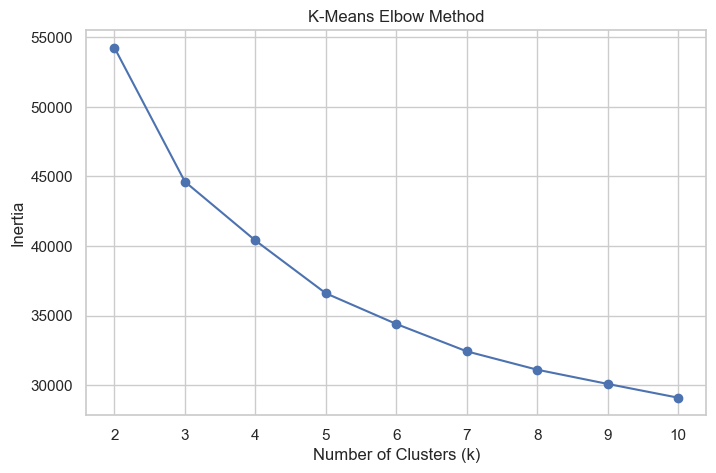

,k,inertia
0,2,54255.426843
1,3,44624.568957
2,4,40397.403917
3,5,36603.072516
4,6,34398.288116
5,7,32430.692467
6,8,31110.442142
7,9,30089.086055
8,10,29099.758675


In [334]:
features = NUMERIC_MODEL_FEATURES + CATEGORICAL_MODEL_FEATURES

preprocessor = make_preprocessor(NUMERIC_MODEL_FEATURES, CATEGORICAL_MODEL_FEATURES)
X_processed = preprocessor.fit_transform(cleaned[features])

inertias = []
k_values = range(2, 11)

for k in k_values:
    kmeans = KMeans(n_clusters=k, random_state=RANDOM_STATE, n_init=20)
    kmeans.fit(X_processed)
    inertias.append(kmeans.inertia_)

plt.figure(figsize=(8, 5))
plt.plot(list(k_values), inertias, marker="o")
plt.title("K-Means Elbow Method")
plt.xlabel("Number of Clusters (k)")
plt.ylabel("Inertia")
plt.show()

elbow_df = pd.DataFrame({"k": list(k_values), "inertia": inertias})
display(elbow_df)

## 24. K-Means clustering + PCA visualization

We cluster movies using metadata and financial features.  
Then PCA projects the processed features into 2D so we can visualize the clusters.

Important: score is **not** used as a clustering input. We compare average score after clustering.

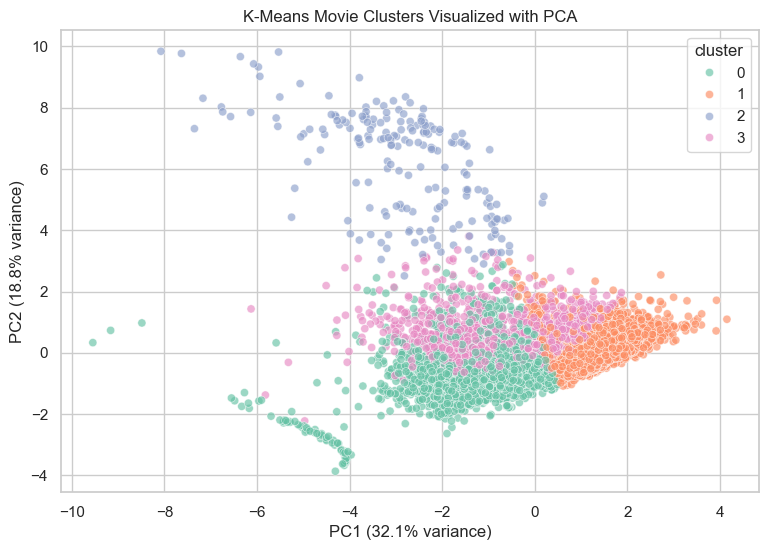

In [335]:
kmeans = KMeans(n_clusters=4, random_state=RANDOM_STATE, n_init=20)
labels = kmeans.fit_predict(X_processed)

pca = PCA(n_components=2, random_state=RANDOM_STATE)
components = pca.fit_transform(X_processed)

clustered = cleaned.copy()
clustered["cluster"] = labels
clustered["pca_1"] = components[:, 0]
clustered["pca_2"] = components[:, 1]

plt.figure(figsize=(9, 6))
sns.scatterplot(
    data=clustered,
    x="pca_1",
    y="pca_2",
    hue="cluster",
    palette="Set2",
    alpha=0.65,
    s=35,
)

plt.title("K-Means Movie Clusters Visualized with PCA")
plt.xlabel(f"PC1 ({pca.explained_variance_ratio_[0]:.1%} variance)")
plt.ylabel(f"PC2 ({pca.explained_variance_ratio_[1]:.1%} variance)")
plt.show()

## 25. Cluster profiles

These summaries help interpret what each cluster represents.

In [336]:
cluster_profile = (
    clustered.groupby("cluster")
    .agg(
        movie_count=("title", "count"),
        avg_score=("score", "mean"),
        median_budget=("budget", "median"),
        median_revenue=("revenue", "median"),
        median_profit=("profit", "median"),
        median_roi=("roi", "median"),
        median_year=("release_year", "median"),
        top_genre=("main_genre", lambda s: s.value_counts().index[0]),
        top_language=("language", lambda s: s.value_counts().index[0]),
        top_country=("country", lambda s: s.value_counts().index[0]),
    )
    .round(3)
    .reset_index()
)

display(cluster_profile)

,cluster,movie_count,avg_score,median_budget,median_revenue,median_profit,median_roi,median_year,top_genre,top_language,top_country
0,0,4016,63.930,20000000.0,28565459.5,5270200.5,0.367,2013.0,Drama,English,AU
1,1,4189,65.008,105400000.0,462439605.0,358120106.0,3.601,2017.0,Action,English,AU
2,2,195,67.862,450000.0,100216295.0,99550000.0,127.860,2009.0,Drama,English,AU
3,3,1567,66.356,20000000.0,63465522.0,43423795.0,2.479,1985.0,Drama,English,AU


## 26. Final takeaway cells

We can adjust this stuff later for the report, but these are the main points shown by the notebook.

In [337]:
print("Main regression takeaway:")
print(
    "The improved regression model performs better than the mean baseline and the simple budget/revenue baseline, "
    "but the R^2 remains modest. This suggests that movie scores are only partially explained by the available "
    "metadata and financial features."
)

print("\nMain classification takeaway:")
print(
    "The logistic regression classifier beats the majority-class baseline, showing that the features contain some "
    "signal for distinguishing low, medium, and high score groups."
)

print("\nMain clustering takeaway:")
print(
    "K-Means and PCA provide an exploratory view of groups of movies based on metadata and financial features. "
    "Because score was not used as a clustering input, average score can be compared afterward as an interpretation step."
)

Main regression takeaway:
The improved regression model performs better than the mean baseline and the simple budget/revenue baseline, but the R^2 remains modest. This suggests that movie scores are only partially explained by the available metadata and financial features.

Main classification takeaway:
The logistic regression classifier beats the majority-class baseline, showing that the features contain some signal for distinguishing low, medium, and high score groups.

Main clustering takeaway:
K-Means and PCA provide an exploratory view of groups of movies based on metadata and financial features. Because score was not used as a clustering input, average score can be compared afterward as an interpretation step.
